In [77]:
import numpy as np
from sklearn.manifold import TSNE
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from common_utils import load_dataframe

In [78]:
df = load_dataframe(Path("results/llms/2026-01-26_14-12-25/progressive_learner.xlsx"))

# Ensure iteration is numeric and sorted
df["iteration"] = pd.to_numeric(df["iteration"], errors="coerce")
df = df.dropna(subset=["iteration"]).sort_values("iteration").reset_index(drop=True)

display(df[["iteration"] + [c for c in df.columns if c in ["train_spearman","train_pearson",
                                                          "validation_Aggregated_spearman","validation_Aggregated_pearson",
                                                          "test_Aggregated_spearman","test_Aggregated_pearson"]]].head())
print("Rows:", len(df), "| Iterations:", df["iteration"].min(), "->", df["iteration"].max())


,iteration,train_spearman,train_pearson
0,0,-,-
1,1,0.912295,0.889998
2,2,0.920086,0.883432
3,3,0.901789,0.866248
4,4,0.931811,0.888262


Rows: 10 | Iterations: 0 -> 9


In [79]:

def plot_single_series(x, y, title, y_label):
    # Force numeric (turns "-", "", "None", etc. into NaN)
    x_num = pd.to_numeric(x, errors="coerce")
    y_num = pd.to_numeric(y, errors="coerce")

    # Keep only valid rows
    mask = x_num.notna() & y_num.notna()
    x_num = x_num[mask]
    y_num = y_num[mask]

    # Sort by iteration (helps if Excel is out of order)
    order = x_num.argsort()
    x_num = x_num.iloc[order]
    y_num = y_num.iloc[order]

    plt.figure()
    plt.plot(x_num, y_num, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_multi_series(x, series_dict, title, y_label):
    plt.figure()
    for name, y in series_dict.items():
        plt.plot(x, y, marker="o", label=name)
    plt.xlabel("Iteration")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


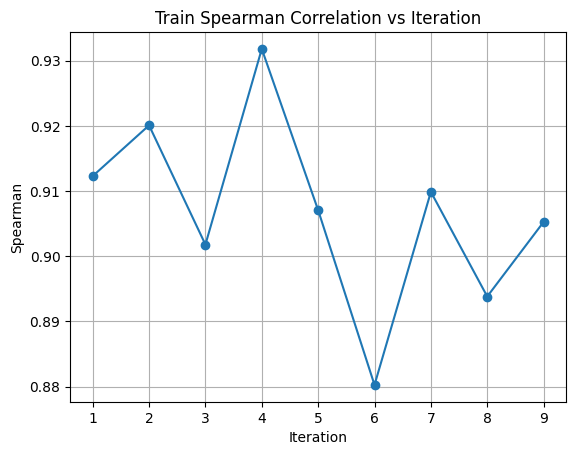

In [80]:
x = df["iteration"]
plot_single_series(
    x=x,
    y=df["train_spearman"],
    title="Train Spearman Correlation vs Iteration",
    y_label="Spearman"
)


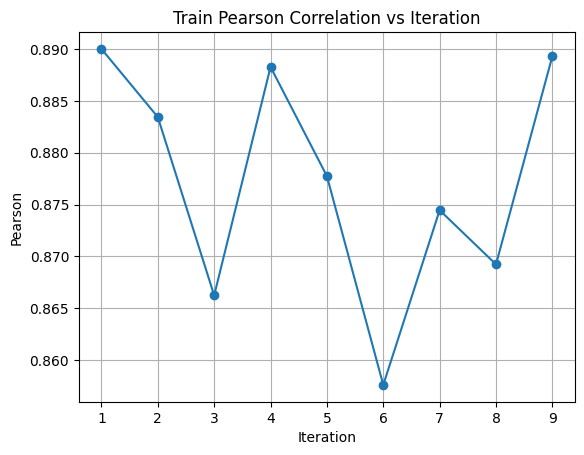

In [81]:
x = df["iteration"]
plot_single_series(
    x=x,
    y=df["train_pearson"],
    title="Train Pearson Correlation vs Iteration",
    y_label="Pearson"
)


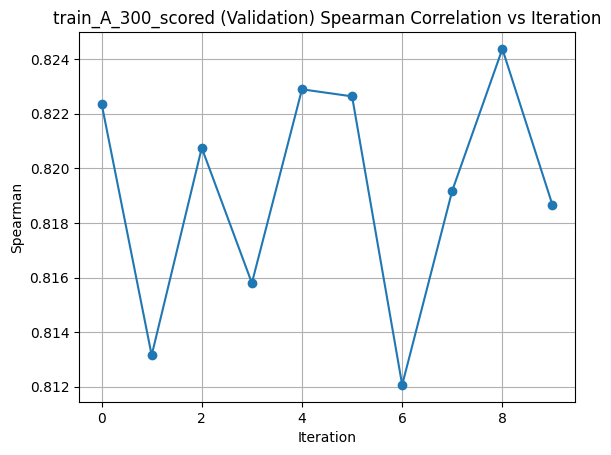

In [82]:
x = df["iteration"]
plot_single_series(
    x=x,
    y=df["validation_1_spearman"],
    title="train_A_300_scored (Validation) Spearman Correlation vs Iteration",
    y_label="Spearman"
)


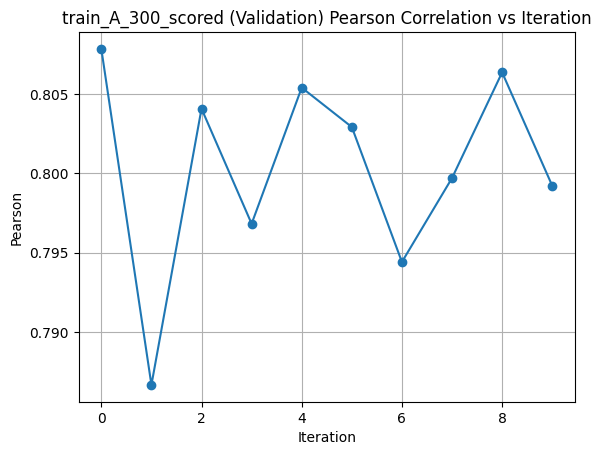

In [83]:
x = df["iteration"]
plot_single_series(
    x=x,
    y=df["validation_1_pearson"],
    title="train_A_300_scored (Validation) Pearson Correlation vs Iteration",
    y_label="Pearson"
)


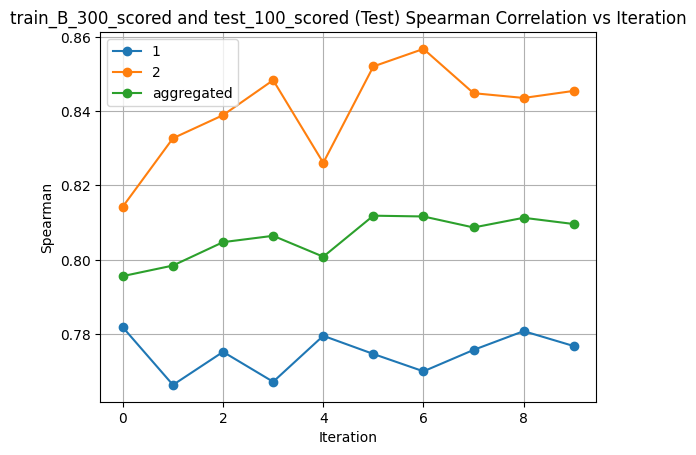

In [84]:
x = df["iteration"]
plot_multi_series(
    x=x,
    series_dict={
        "1": df["test_1_spearman"],
        "2": df["test_2_spearman"],
        "aggregated": df["test_aggregated_spearman"],
    },
    title="train_B_300_scored and test_100_scored (Test) Spearman Correlation vs Iteration",
    y_label="Spearman"
)


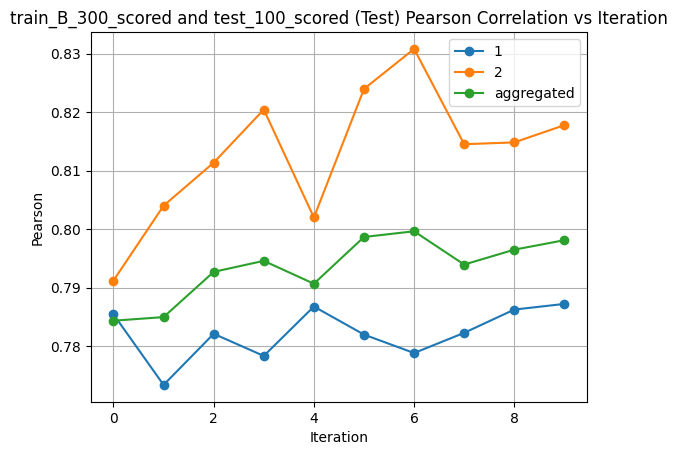

In [85]:
x = df["iteration"]
plot_multi_series(
    x=x,
    series_dict={
        "1": df["test_1_pearson"],
        "2": df["test_2_pearson"],
        "aggregated": df["test_aggregated_pearson"],
    },
    title="train_B_300_scored and test_100_scored (Test) Pearson Correlation vs Iteration",
    y_label="Pearson"
)


In [86]:
# # Path to embeddings
# embeddings_path = "results/llms/2026-01-26_09-58-46/it_10/embeddings_10.npz"
#
# # Load embeddings
# data = np.load(embeddings_path)
#
# # Try common keys
# if "embeddings" in data:
#     X = data["embeddings"]
# else:
#     # fallback: take first array
#     X = data[list(data.keys())[0]]
#
# print("Loaded embeddings shape:", X.shape, "| dtype:", X.dtype)
#
# # Ensure numeric dtype (good for sklearn)
# X = np.asarray(X, dtype=np.float32, order="C")
#
# # Run t-SNE (CPU)
# tsne = TSNE(
#     n_components=2,
#     perplexity=30,
#     learning_rate="auto",
#     init="random",
#     random_state=42,
#     verbose=1,
# )
# X_2d = tsne.fit_transform(X)
#
# # Plot
# plt.figure(figsize=(8, 8))
# plt.scatter(X_2d[:, 0], X_2d[:, 1], s=1, alpha=0.5)
# plt.title("t-SNE of Sentence Embeddings (Iteration 10)")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.grid(True)
# plt.show()

In [1]:
import numpy as np

def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def random_cosine_stats(X: np.ndarray, pairs: int = 200_000, seed: int = 42) -> dict:
    """
    Sample random pairs and compute cosine stats.
    X: (N,D) float32/float64
    """
    rng = np.random.default_rng(seed)
    N = X.shape[0]
    i = rng.integers(0, N, size=pairs, dtype=np.int64)
    j = rng.integers(0, N, size=pairs, dtype=np.int64)
    mask = i != j
    i, j = i[mask], j[mask]

    Xn = l2_normalize(X.astype(np.float32, copy=False))
    cos = np.sum(Xn[i] * Xn[j], axis=1)

    qs = np.quantile(cos, [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    return {
        "n_pairs": int(cos.shape[0]),
        "mean": float(cos.mean()),
        "std": float(cos.std()),
        "min": float(cos.min()),
        "max": float(cos.max()),
        "quantiles": {k: float(v) for k, v in zip(["p01","p05","p10","p25","p50","p75","p90","p95","p99"], qs)}
    }

class WhiteningTransform:
    """
    Fit: mean + PCA whitening matrix (optionally keep top components).
    Apply: (x - mu) @ W
    """
    def __init__(self, eps: float = 1e-5, n_components: int | None = None):
        self.eps = eps
        self.n_components = n_components
        self.mu = None
        self.W = None  # (D, K) if n_components else (D, D)

    def fit(self, X: np.ndarray) -> "WhiteningTransform":
        X = X.astype(np.float32, copy=False)
        self.mu = X.mean(axis=0, keepdims=True)
        Xc = X - self.mu

        # covariance
        cov = (Xc.T @ Xc) / max(1, (Xc.shape[0] - 1))

        # eigen-decomp (cov is symmetric)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        if self.n_components is not None:
            eigvals = eigvals[: self.n_components]
            eigvecs = eigvecs[:, : self.n_components]

        self.W = eigvecs @ np.diag(1.0 / np.sqrt(eigvals + self.eps))
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mu is None or self.W is None:
            raise RuntimeError("WhiteningTransform must be fit() before transform().")
        X = X.astype(np.float32, copy=False)
        return (X - self.mu) @ self.W

    def save_npz(self, path: str) -> None:
        np.savez(path, mu=self.mu.astype(np.float32), W=self.W.astype(np.float32), eps=np.float32(self.eps))

    @staticmethod
    def load_npz(path: str) -> "WhiteningTransform":
        data = np.load(path)
        obj = WhiteningTransform(eps=float(data["eps"]))
        obj.mu = data["mu"]
        obj.W = data["W"]
        return obj

In [4]:
def print_cosine_stats(stats: dict) -> None:
    print(f"Pairs: {stats['n_pairs']}")
    print(f"Mean: {stats['mean']:.6f} | Std: {stats['std']:.6f}")
    print(f"Min: {stats['min']:.6f} | Max: {stats['max']:.6f}")
    print("Quantiles:")
    for k, v in stats["quantiles"].items():
        print(f"  {k}: {v:.6f}")

In [6]:
# import the embeddings from the npz file
embeddings_path = "results/llms/2026-01-26_22-32-32/it_00/embeddings_00.npz"
data = np.load(embeddings_path, allow_pickle=True)
X_raw = data["embeddings"].astype(np.float32, copy=False)
# X_raw: (N,D)
print("RAW:")
print_cosine_stats(random_cosine_stats(X_raw))

# Center only
X_centered = X_raw - X_raw.mean(axis=0, keepdims=True)
print("CENTERED:")
print_cosine_stats(random_cosine_stats(X_centered))

# Whiten
wt = WhiteningTransform(eps=1e-5, n_components=None).fit(X_raw)
X_white = wt.transform(X_raw)
print("WHITEN:")
print_cosine_stats(random_cosine_stats(X_white))

RAW:
Pairs: 199998
Mean: 0.725444 | Std: 0.074510
Min: 0.377535 | Max: 0.967867
Quantiles:
  p01: 0.545733
  p05: 0.599611
  p10: 0.627378
  p25: 0.674318
  p50: 0.728101
  p75: 0.779622
  p90: 0.820721
  p95: 0.842952
  p99: 0.878607
CENTERED:
Pairs: 199998
Mean: 0.001630 | Std: 0.161465
Min: -0.539696 | Max: 0.896957
Quantiles:
  p01: -0.315777
  p05: -0.238071
  p10: -0.193409
  p25: -0.112884
  p50: -0.012488
  p75: 0.101532
  p90: 0.214925
  p95: 0.288847
  p99: 0.438466
WHITEN:
Pairs: 199998
Mean: -0.000028 | Std: 0.036682
Min: -0.155481 | Max: 0.617967
Quantiles:
  p01: -0.079724
  p05: -0.056982
  p10: -0.044777
  p25: -0.024337
  p50: -0.001321
  p75: 0.022462
  p90: 0.045133
  p95: 0.060192
  p99: 0.096369


In [3]:
from  common_utils import *
from pathlib import Path
df_0 = load_dataframe(Path("results/llms/2026-01-28_16-03-23/it_00/active_sampling_results_00.xlsx"))
save_dataframe(df_0, Path("results/llms/2026-01-28_16-03-23/active_sampling_results.xlsx"))

FileNotFoundError: The file does not exist: results/llms/2026-01-28_16-03-23/it_01/active_sampling_results_01.xlsx